In [1]:
import os.path

import pyranges

gencode = pyranges.read_gtf("../data/gencode.v40.basic.annotation.gtf")

genes_from_gencode = (
    gencode
    [(gencode['Feature'] == 'gene')]
    [['Chromosome', 'Start', 'End', 'gene_id']]
)

genes_from_gencode['gene_id'] = genes_from_gencode['gene_id'].str.split('.').str[0]

genes_from_gencode

,Chromosome,Start,End,gene_id
0,chr1,11868,14409,ENSG00000223972
12,chr1,14403,29570,ENSG00000227232
25,chr1,17368,17436,ENSG00000278267
28,chr1,29553,31109,ENSG00000243485
36,chr1,30365,30503,ENSG00000284332
...,...,...,...,...
1926897,chrM,14148,14673,ENSG00000198695
1926902,chrM,14673,14742,ENSG00000210194
1926905,chrM,14746,15887,ENSG00000198727
1926910,chrM,15887,15953,ENSG00000210195


In [2]:
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

with open("../data/rnaseq/gm12878_read_count.txt", "r") as f:
    f.readline()
    gm12878_counts_df = pd.read_csv(f, index_col=0, sep="\t")


with open("../data/rnaseq/h1esc_read_count.txt", "r") as f:
    f.readline()
    h1esc_counts_df = pd.read_csv(f, index_col=0, sep="\t")

with open("../data/rnaseq/hffc6_read_count.txt", "r") as f:
    f.readline()
    hffc6_counts_df = pd.read_csv(f, index_col=0, sep="\t")

gm12878_counts_df = gm12878_counts_df[['ENCFF800HIP.filtered.bam', 'ENCFF991KKX.filtered.bam']].T
h1esc_counts_df = h1esc_counts_df[['ENCFF675NTU.filtered.bam', 'ENCFF379NOY.filtered.bam']].T
hffc6_counts_df = hffc6_counts_df[['ENCFF307KUI.filtered.bam', 'ENCFF294BSI.filtered.bam', 'ENCFF937TEI.filtered.bam']].T

def compute_deseq_stats_for_2_celllines(cellline1_counts_df, cellline2_counts_df, cellline1_name="CellLine1", cellline2_name="CellLine2"):
    cl1_vs_cl2_counts_df = pd.concat(
        [cellline1_counts_df, cellline2_counts_df]
    )

    cl1_vs_cl2_metadata_df = pd.DataFrame(
        {
            "condition": [cellline1_name] * cellline1_counts_df.shape[0] + [cellline2_name] * cellline2_counts_df.shape[0]
        },
        index=cl1_vs_cl2_counts_df.index,
    )

    inference = DefaultInference(n_cpus=8)
    dds = DeseqDataSet(
        counts=cl1_vs_cl2_counts_df,
        metadata=cl1_vs_cl2_metadata_df,
        design="~condition",
        refit_cooks=True,
        inference=inference,
    )

    dds.deseq2()
    stats = DeseqStats(dds, contrast=["condition", cellline2_name, cellline1_name])
    stats.summary()

    stats.lfc_shrink(coeff=f"condition[T.{cellline2_name}]")
    # stats.lfc_shrink(coeff=stats.LFC.columns[1])

    results_df = stats.results_df.dropna()
    results_df['symbol'] = results_df.index
    return results_df

if os.path.exists("../data/deseq/gm12878_vs_h1esc_results.parquet"):
    gm12878_vs_h1esc_results_df = pd.read_parquet("../data/deseq/gm12878_vs_h1esc_results.parquet")
else:
    gm12878_vs_h1esc_results_df = compute_deseq_stats_for_2_celllines(
        gm12878_counts_df,
        h1esc_counts_df,
        cellline1_name="GM12878",
        cellline2_name="H1ESC"
    )
    gm12878_vs_h1esc_results_df.to_parquet("../data/deseq/gm12878_vs_h1esc_results.parquet")

if os.path.exists("../data/deseq/h1esc_vs_hffc6_results.parquet"):
    h1esc_vs_hffc6_results_df = pd.read_parquet("../data/deseq/h1esc_vs_hffc6_results.parquet")
else:
    h1esc_vs_hffc6_results_df = compute_deseq_stats_for_2_celllines(
        h1esc_counts_df,
        hffc6_counts_df,
        cellline1_name="H1ESC",
        cellline2_name="HFFC6"
    )
    h1esc_vs_hffc6_results_df.to_parquet("../data/deseq/h1esc_vs_hffc6_results.parquet")

if os.path.exists("../data/deseq/gm12878_vs_hffc6_results.parquet"):
    gm12878_vs_hffc6_results_df = pd.read_parquet("../data/deseq/gm12878_vs_hffc6_results.parquet")
else:
    gm12878_vs_hffc6_results_df = compute_deseq_stats_for_2_celllines(
        gm12878_counts_df,
        hffc6_counts_df,
        cellline1_name="GM12878",
        cellline2_name="HFFC6",
    )
    gm12878_vs_hffc6_results_df.to_parquet("../data/deseq/gm12878_vs_hffc6_results.parquet")

In [3]:
hffc6_vs_gm12878_results_df = gm12878_vs_hffc6_results_df.copy()
hffc6_vs_gm12878_results_df['log2FoldChange'] = -hffc6_vs_gm12878_results_df['log2FoldChange']
hffc6_vs_gm12878_results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,symbol
Geneid,,,,,,,
ENSG00000227232.5,4.876008,-4.555738,2.193361,2.181255,0.029165,0.070721,ENSG00000227232.5
ENSG00000278267.1,1.138906,0.250018,1.193712,-0.610732,0.541377,0.771679,ENSG00000278267.1
ENSG00000238009.6,1.072304,0.503159,1.251394,-1.183214,0.236725,0.420047,ENSG00000238009.6
ENSG00000233750.3,0.353368,0.166119,1.111811,-0.463364,0.643103,0.836999,ENSG00000233750.3
ENSG00000268903.1,8.401750,6.974442,2.777177,-3.118622,0.001817,0.005614,ENSG00000268903.1
...,...,...,...,...,...,...,...
ENSG00000198695.2,1520.630326,0.225613,0.157064,-1.464713,0.142999,0.279301,ENSG00000198695.2
ENSG00000210194.1,16.391290,1.314085,0.595190,-2.590932,0.009572,0.025888,ENSG00000210194.1
ENSG00000198727.2,30956.220844,0.797251,0.190630,-4.278273,0.000019,0.000076,ENSG00000198727.2


In [4]:
gene_to_closest_avg_enhancer_all = pd.read_parquet("../data/whole_chromosomes/genes_all_cell_lines_v3.snappy.parquet")
gm12878_gene_to_closest_avg_enhancer_all = gene_to_closest_avg_enhancer_all[gene_to_closest_avg_enhancer_all['cell_line'] == 'GM12878'].set_index('gene_id').drop(columns=['cell_line'])
h1esc_gene_to_closest_avg_enhancer_all = gene_to_closest_avg_enhancer_all[gene_to_closest_avg_enhancer_all['cell_line'] == 'H1ESC'].set_index('gene_id').drop(columns=['cell_line'])
hffc6_gene_to_closest_avg_enhancer_all = gene_to_closest_avg_enhancer_all[gene_to_closest_avg_enhancer_all['cell_line'] == 'HFFC6'].set_index('gene_id').drop(columns=['cell_line'])

def add_chromosome_and_quartiles(df, name):
    df = df.merge(genes_from_gencode[['gene_id', 'Chromosome']], left_index=True, right_on='gene_id', how='left').set_index('gene_id')

    def compute_quartiles(group):
        q1 = group['min_dist'].quantile(0.33)
        q3 = group['min_dist'].quantile(0.67)
        def label_quartile(x):
            if x <= q1:
                return 'small'
            elif x <= q3:
                return 'mid'
            else:
                return 'large'
        group['quartile_cat'] = group['min_dist'].apply(label_quartile)
        return group

    df = df.groupby('Chromosome', group_keys=False).apply(compute_quartiles, include_groups=False)
    return df

gm12878_gene_to_closest_avg_enhancer_all = add_chromosome_and_quartiles(gm12878_gene_to_closest_avg_enhancer_all, 'gm12878')
hffc6_gene_to_closest_avg_enhancer_all = add_chromosome_and_quartiles(hffc6_gene_to_closest_avg_enhancer_all, 'hffc6')
h1esc_gene_to_closest_avg_enhancer_all = add_chromosome_and_quartiles(h1esc_gene_to_closest_avg_enhancer_all, 'h1esc')

In [5]:
gm12878_gene_to_closest_avg_enhancer_all

,project_id,avg_dist,min_dist,max_dist,quartile_cat
gene_id,,,,,
ENSG00000094914,whole_all_vs_all_gm12878_fix,85.483211,1.851314,203.034027,mid
ENSG00000258012,whole_all_vs_all_gm12878_fix,140.225051,8.961069,251.205017,mid
ENSG00000257596,whole_all_vs_all_gm12878_fix,85.879081,4.000490,203.226471,mid
ENSG00000118971,whole_all_vs_all_gm12878_fix,89.018759,3.265652,197.030502,mid
ENSG00000111671,whole_all_vs_all_gm12878_fix,88.655649,1.553416,196.678360,small
...,...,...,...,...,...
ENSG00000197696,whole_all_vs_all_gm12878_fix,77.057342,1.317909,260.666382,mid
ENSG00000260608,whole_all_vs_all_gm12878_fix,79.975464,0.523023,277.504913,small
ENSG00000259468,whole_all_vs_all_gm12878_fix,114.043947,5.036004,174.152191,large


In [30]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np
import joypy
from matplotlib import cm

def plot_distance_vs_expression_correlation(
    cell1_distances_df,
    cell2_distances_df,
    deseq_results_df,
    cell1_name,
    cell2_name,
    figsize=(20, 20),
    plot_path=None,
    color_map=cm.viridis,
    font_size=24,
    log2fc_threshold=2,
    padj_threshold=0.05
):
    deseq_results_df = deseq_results_df.copy()

    deseq_results_df.index = deseq_results_df.index.str.split('.').str[0]

    deseq_results_df = deseq_results_df[
        (deseq_results_df["padj"] < padj_threshold)
        & (deseq_results_df["log2FoldChange"].abs() > log2fc_threshold)
    ]

    cell1_distances_df = cell1_distances_df.copy()
    cell1_distances_df['norm_min_dist'] = (
        (cell1_distances_df['min_dist'] - cell1_distances_df['min_dist'].min()) / (cell1_distances_df['min_dist'].max() - cell1_distances_df['min_dist'].min())
    )

    cell2_distances_df = cell2_distances_df.copy()
    cell2_distances_df['norm_min_dist'] = (
        (cell2_distances_df['min_dist'] - cell2_distances_df['min_dist'].min()) / (cell2_distances_df['min_dist'].max() - cell2_distances_df['min_dist'].min())
    )

    combined_df = cell1_distances_df.merge(
        cell2_distances_df,
        left_index=True,
        right_index=True,
        how="inner",
        suffixes=(f"_{cell1_name}", f"_{cell2_name}")
    )

    combined_df["log_dist_ratio"] = np.log2(combined_df[f"min_dist_{cell2_name}"] / combined_df[f"min_dist_{cell1_name}"])
    combined_df["dist_diff"] = combined_df[f"min_dist_{cell2_name}"] - combined_df[f"min_dist_{cell1_name}"]

    combined_df["norm_dist_diff"] = combined_df[f"norm_min_dist_{cell2_name}"] - combined_df[f"norm_min_dist_{cell1_name}"]
    combined_df["log_norm_dist_ratio"] = np.log2(combined_df[f"norm_min_dist_{cell2_name}"] / combined_df[f"norm_min_dist_{cell1_name}"])

    # Define link change categories
    def get_link_change(row):
        if row[f"has_link_{cell1_name}"] and not row[f"has_link_{cell2_name}"]:
            return f"Only {cell1_name}"
        elif not row[f"has_link_{cell1_name}"] and row[f"has_link_{cell2_name}"]:
            return f"Only {cell2_name}"
        elif row[f"has_link_{cell1_name}"] and row[f"has_link_{cell2_name}"]:
            return "Both"
        else:
            return "Neither"

    # combined_df["link_status"] = combined_df.apply(get_link_change, axis=1)

    def get_quartile_change(row):
        q1 = row[f"quartile_cat_{cell1_name}"]
        q2 = row[f"quartile_cat_{cell2_name}"]

        if q1 == q2:
            return "No change"

        categories = ["small", "mid", "large"]
        idx1 = categories.index(q1)
        idx2 = categories.index(q2)

        if idx1 > idx2:
            return f"Decreased ({q1} to {q2})"
        else:
            return f"Increased ({q1} to {q2})"

    combined_df["quartile_change"] = combined_df.apply(get_quartile_change, axis=1)

    merged_df = combined_df.merge(
        deseq_results_df[["log2FoldChange", "padj"]],
        left_index=True,
        right_index=True,
        how="inner"
    )

    merged_df_for_correlation = merged_df.copy()
    merged_df_for_correlation = merged_df_for_correlation[
        ~merged_df_for_correlation["quartile_change"].isin([
            "No change",
            "Increased (small to mid)",
            "Increased (mid to large)",
            "Decreased (large to mid)",
            "Decreased (mid to small)",
        ])
    ]

    merged_df_for_plotting = merged_df.copy()
    merged_df_for_plotting = merged_df_for_plotting[
        ~merged_df_for_plotting["quartile_change"].isin([
            "Increased (small to mid)",
            "Increased (mid to large)",
            "Decreased (large to mid)",
            "Decreased (mid to small)",
        ])
    ]

    # pearson_r, pearson_p = pearsonr(merged_df_for_correlation["log_dist_ratio"], merged_df_for_correlation["log2FoldChange"], alternative='two-sided') - data is not normally distributed
    spearman_r, spearman_p = spearmanr(merged_df_for_correlation["dist_diff"], merged_df_for_correlation["log2FoldChange"], alternative='two-sided')

    quartile_order = [
        "Increased (small to large)",
        # "Increased (mid to large)",
        # "Increased (small to mid)",
        "No change",
        "Decreased (large to small)",
        # "Decreased (mid to small)",
        # "Decreased (large to mid)"
    ]

    available_categories = merged_df_for_plotting["quartile_change"].unique()
    plot_order = [cat for cat in quartile_order if cat in available_categories]

    plot_data = {}
    for category in plot_order:
        subset = merged_df_for_plotting[merged_df_for_plotting["quartile_change"] == category]
        if len(subset) >= 3:
            plot_data[category] = subset["log2FoldChange"]

    # Create figure
    fig, axes = joypy.joyplot(
        plot_data,
        figsize=figsize,
        colormap=color_map,
        overlap=0.7,
        linewidth=1,
        alpha=0.8,
        grid="y",
        legend=False,
        title=f"Expression Change by Distance Change for {cell1_name} vs {cell2_name}\n" +
              # f"Pearson r: {pearson_r:.3f} (p: {pearson_p:.2e}) | " +
              f"Spearman r: {spearman_r:.3f} (p: {spearman_p:.2e})",
        range_style='own',

    )

    # print(f'Pearson r: {pearson_r:.3f}, p-value: {pearson_p:.2e}')
    print(f'Spearman r: {spearman_r:.3f}, p-value: {spearman_p:.2e}')

    plt.xlabel("Log2 Fold Change", fontsize=font_size, fontweight='bold')

    for ax in axes[:-1]:  # Skip the last ax which is just for the x-axis
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

    for ax in axes[:-1]:  # Skip the last ax which is just for the x-axis
        ax.axvline(x=-log2fc_threshold, color='gray', linestyle='--', alpha=0.7, linewidth=1)
        ax.axvline(x=log2fc_threshold, color='gray', linestyle='--', alpha=0.7, linewidth=1)

    title = axes[-1].get_title()
    axes[-1].set_title(title, fontsize=font_size, fontweight='bold')
    for ax in axes:
        label = ax.get_yticklabels()
        ax.set_yticklabels(label, fontsize=font_size, fontweight='bold')
    # for ax, category in zip(axes[:-1], plot_order):
    #     if category in plot_data:
    #         mean_value = plot_data[category].mean()
    #         ax.axvline(x=mean_value, color='red', linestyle='-', alpha=0.7, linewidth=1)

    handles = []
    for i, label in enumerate(plot_data.keys()):
        color = color_map(i / len(plot_data))
        handles.append(plt.Rectangle((0,0), 1, 1, color=color, alpha=0.7))

    handles.append(plt.Line2D([0], [0], color='gray', linestyle='--', alpha=0.7))
    legend_labels = list(plot_data.keys()) + [f'Significance threshold (|log2FC| > {log2fc_threshold})']

    # handles.append(plt.Line2D([0], [0], color='red', linestyle='-', alpha=0.7))
    # legend_labels.append('Mean log2FC for each quartile change')

    plt.figlegend(
        handles, legend_labels,
        loc="upper left",
        bbox_to_anchor=(0.99, 0.98),
        fontsize=font_size,
        prop={'weight':'bold', 'size': font_size}
    )

    if plot_path:
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    else:
        plt.tight_layout()

    return fig, merged_df

/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/1122956638.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(label, fontsize=font_size, fontweight='bold')


Spearman r: -0.591, p-value: 1.02e-19


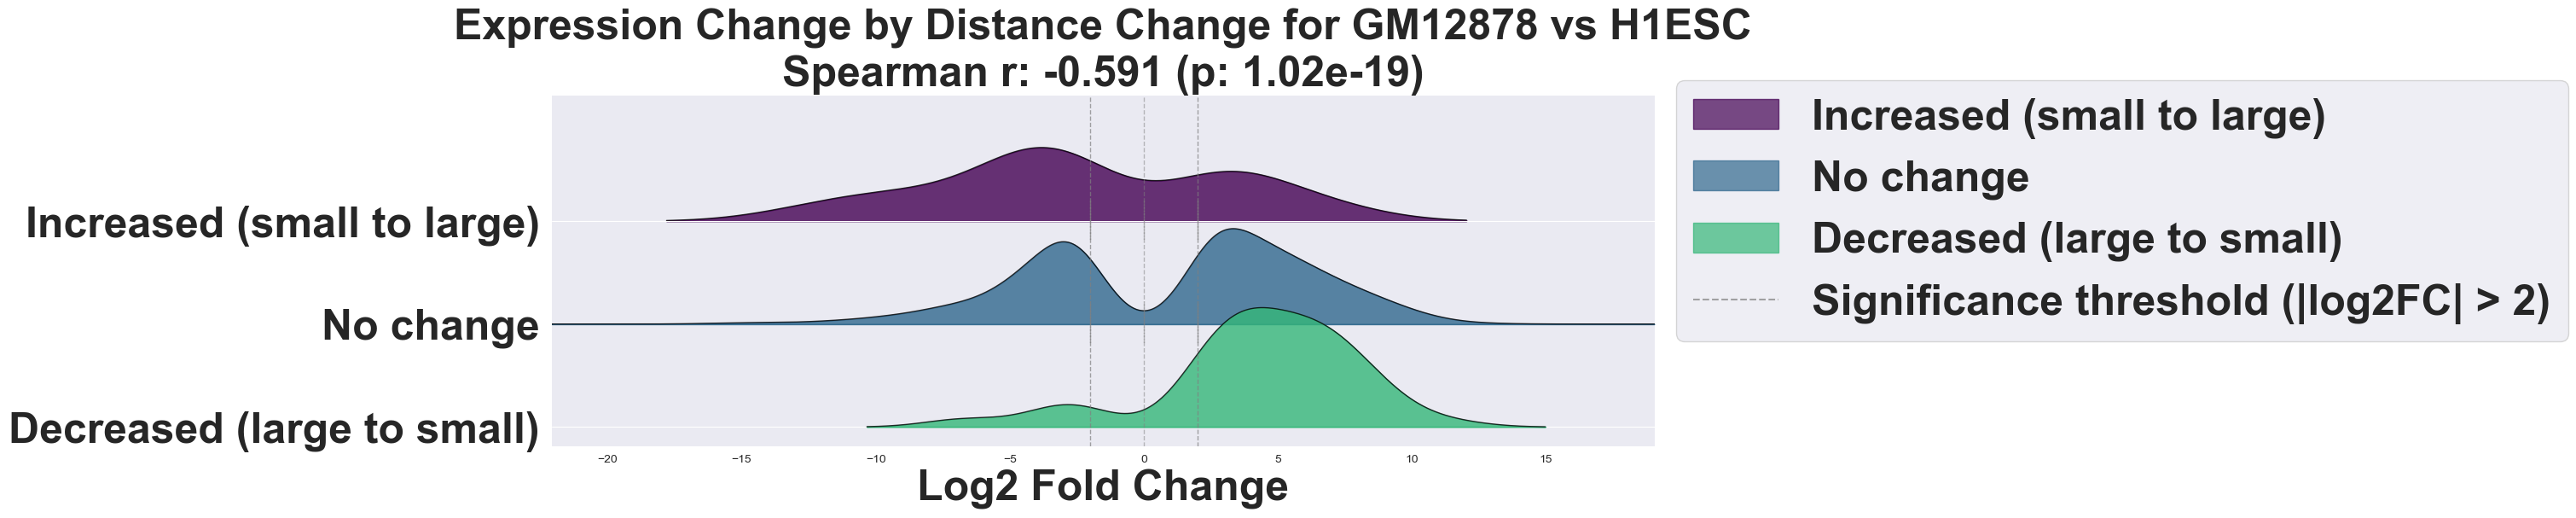

,project_id_GM12878,avg_dist_GM12878,min_dist_GM12878,max_dist_GM12878,quartile_cat_GM12878,norm_min_dist_GM12878,project_id_H1ESC,avg_dist_H1ESC,min_dist_H1ESC,max_dist_H1ESC,quartile_cat_H1ESC,norm_min_dist_H1ESC,log_dist_ratio,dist_diff,norm_dist_diff,log_norm_dist_ratio,quartile_change,log2FoldChange,padj
ENSG00000130590,whole_all_vs_all_gm12878_fix,61.195341,1.684371,165.549667,mid,0.009117,whole_all_vs_all_h1esc_fix,50.701737,0.242875,137.455368,small,0.002861,-2.793925,-1.441496,-0.006256,-1.672063,Decreased (mid to small),-4.041699,2.790927e-123
ENSG00000088367,whole_all_vs_all_gm12878_fix,48.392914,1.632099,146.474762,mid,0.008834,whole_all_vs_all_h1esc_fix,43.990553,8.139631,108.850029,large,0.096598,2.318235,6.507533,0.087764,3.450853,Increased (mid to large),6.011779,3.544214e-115
ENSG00000187621,whole_all_vs_all_gm12878_fix,98.752708,1.439029,215.184906,mid,0.007788,whole_all_vs_all_h1esc_fix,77.471544,9.807832,176.357330,large,0.116400,2.768839,8.368803,0.108612,3.901664,Increased (mid to large),-2.452700,3.655704e-02
ENSG00000225187,whole_all_vs_all_gm12878_fix,158.348481,1.070464,232.463394,small,0.005792,whole_all_vs_all_h1esc_fix,91.559368,0.469866,166.877747,small,0.005555,-1.187916,-0.600598,-0.000236,-0.060076,No change,-2.081788,7.656871e-03
ENSG00000157827,whole_all_vs_all_gm12878_fix,183.235579,95.979904,290.479462,mid,0.519910,whole_all_vs_all_h1esc_fix,111.199695,71.618324,168.667709,mid,0.850112,-0.422404,-24.361580,0.330202,0.709391,No change,5.713414,1.844565e-287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000280087,whole_all_vs_all_gm12878_fix,34.259104,2.418102,160.065338,mid,0.013092,whole_all_vs_all_h1esc_fix,38.765621,1.565360,115.612640,mid,0.018559,-0.627381,-0.852742,0.005468,0.503488,No change,8.302962,1.356595e-03
ENSG00000177311,whole_all_vs_all_gm12878_fix,270.255449,141.587143,368.181183,mid,0.766961,whole_all_vs_all_h1esc_fix,83.366715,56.024174,157.140366,mid,0.665004,-1.337569,-85.562973,-0.101957,-0.205791,No change,-3.605678,0.000000e+00
ENSG00000034533,whole_all_vs_all_gm12878_fix,270.255449,141.587143,368.181183,mid,0.766961,whole_all_vs_all_h1esc_fix,83.366715,56.024174,157.140366,mid,0.665004,-1.337569,-85.562973,-0.101957,-0.205791,No change,-7.375199,1.374450e-12
ENSG00000283154,whole_all_vs_all_gm12878_fix,270.255449,141.587143,368.181183,mid,0.766961,whole_all_vs_all_h1esc_fix,83.366715,56.024174,157.140366,mid,0.665004,-1.337569,-85.562973,-0.101957,-0.205791,No change,8.473545,1.085857e-03


In [31]:
fig, corr_data = plot_distance_vs_expression_correlation(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    figsize=(15, 5),
    plot_path="figs/exp4_gm_h1_joy.png",
    log2fc_threshold=2,
    font_size = 36
)
plt.show()
corr_data

Spearman r: -0.559, p-value: 8.23e-19


/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/1122956638.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(label, fontsize=font_size, fontweight='bold')


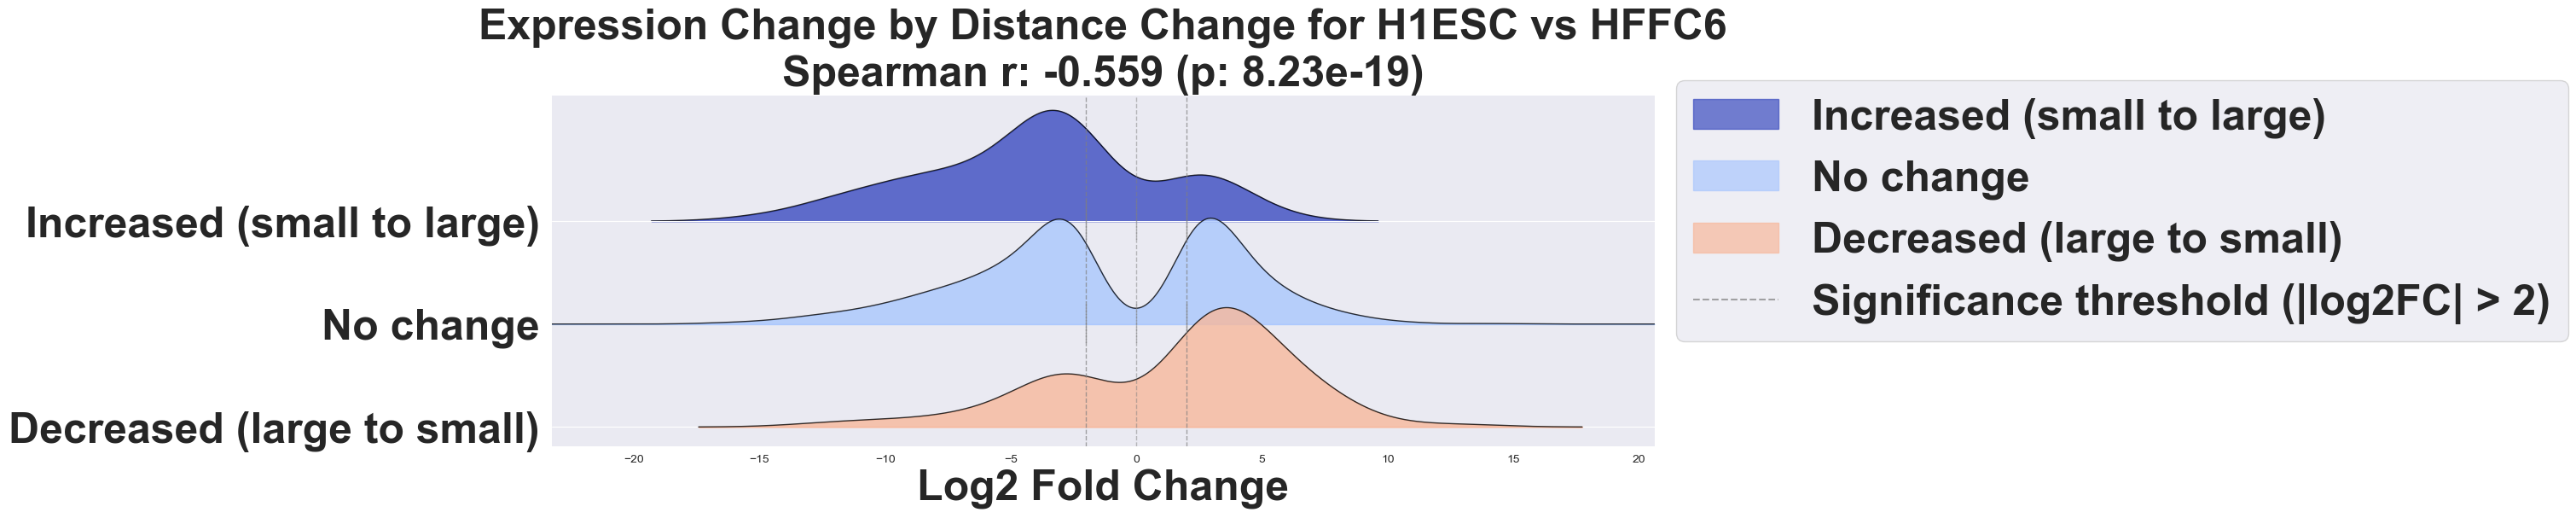

In [33]:
fig, corr_data = plot_distance_vs_expression_correlation(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    figsize=(15, 5),
    plot_path="figs/exp4_h1_hffc_joy.png",
    color_map=cm.coolwarm,
    log2fc_threshold=2,
    font_size = 36
)

plt.show()

Spearman r: -0.580, p-value: 1.89e-17


/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/1122956638.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(label, fontsize=font_size, fontweight='bold')


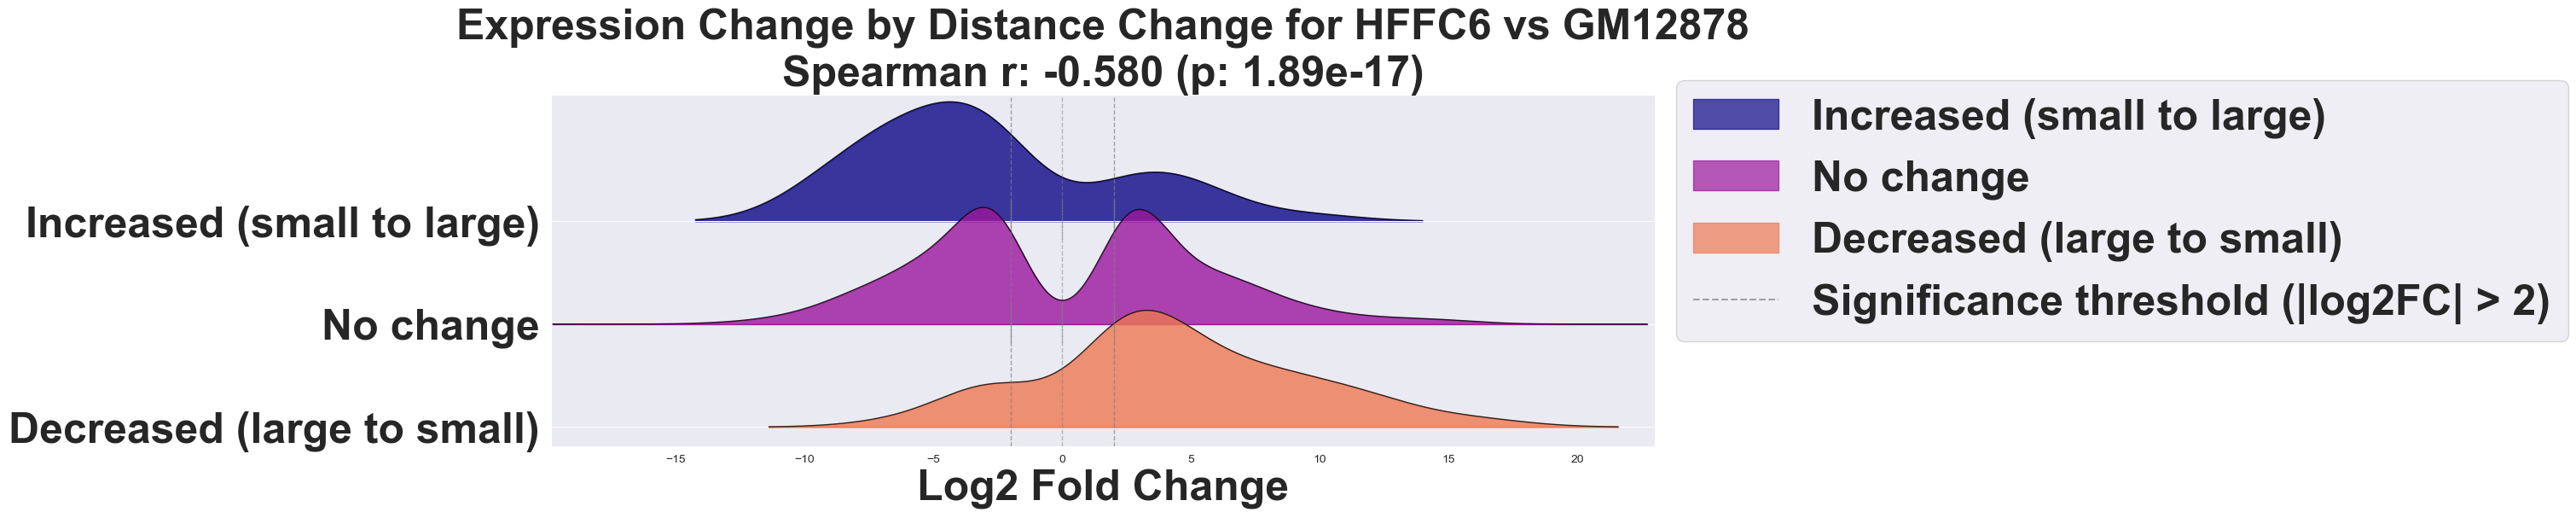

In [34]:
fig, corr_data = plot_distance_vs_expression_correlation(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    figsize=(15, 5),
    plot_path="figs/exp4_hffc_gm_joy.png",
    color_map=cm.plasma,
    log2fc_threshold=2,
    font_size = 36
)

plt.show()

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from gprofiler import GProfiler

gp = GProfiler(
    user_agent='enhancer3d',
    return_dataframe=True,
)

def get_comparison_table_2_cell_lines(
    cell1_distances_df,
    cell2_distances_df,
    deseq_results_df,
    cell1_name,
    cell2_name,
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=True
):
    deseq_results_df = deseq_results_df.copy()
    deseq_results_df.index = deseq_results_df.index.str.split('.').str[0]

    deseq_results_df = deseq_results_df[
        (deseq_results_df["padj"] < padj_threshold)
        & (deseq_results_df["log2FoldChange"].abs() > log2fc_threshold)
    ]

    cell1_distances_df = cell1_distances_df.copy()
    cell1_distances_df['norm_min_dist'] = (
        (cell1_distances_df['min_dist'] - cell1_distances_df['min_dist'].min()) / (cell1_distances_df['min_dist'].max() - cell1_distances_df['min_dist'].min())
    )

    cell2_distances_df = cell2_distances_df.copy()
    cell2_distances_df['norm_min_dist'] = (
        (cell2_distances_df['min_dist'] - cell2_distances_df['min_dist'].min()) / (cell2_distances_df['min_dist'].max() - cell2_distances_df['min_dist'].min())
    )

    combined_df = cell1_distances_df.merge(
        cell2_distances_df,
        left_index=True,
        right_index=True,
        how="inner",
        suffixes=(f"_{cell1_name}", f"_{cell2_name}")
    )

    combined_df["log_dist_ratio"] = np.log2(combined_df[f"min_dist_{cell1_name}"] / combined_df[f"min_dist_{cell2_name}"])
    combined_df["dist_diff"] = combined_df[f"min_dist_{cell1_name}"] - combined_df[f"min_dist_{cell2_name}"]

    combined_df["norm_dist_diff"] = combined_df[f"norm_min_dist_{cell1_name}"] - combined_df[f"norm_min_dist_{cell2_name}"]
    combined_df["log_norm_dist_ratio"] = np.log2(combined_df[f"norm_min_dist_{cell1_name}"] / combined_df[f"norm_min_dist_{cell2_name}"])

    def get_link_change(row):
        if row[f"has_link_{cell1_name}"] and not row[f"has_link_{cell2_name}"]:
            return f"Only {cell1_name}"
        elif not row[f"has_link_{cell1_name}"] and row[f"has_link_{cell2_name}"]:
            return f"Only {cell2_name}"
        elif row[f"has_link_{cell1_name}"] and row[f"has_link_{cell2_name}"]:
            return "Both"
        else:
            return "Neither"

    # combined_df["link_status"] = combined_df.apply(get_link_change, axis=1)

    def get_quartile_change(row):
        q1 = row[f"quartile_cat_{cell1_name}"]
        q2 = row[f"quartile_cat_{cell2_name}"]

        if q1 == q2:
            return "No change"

        categories = ["small", "mid", "large"]
        idx1 = categories.index(q1)
        idx2 = categories.index(q2)

        if idx1 > idx2:
            return f"Decreased ({q1} to {q2})"
        else:
            return f"Increased ({q1} to {q2})"

    combined_df["quartile_change"] = combined_df.apply(get_quartile_change, axis=1)

    merged_df = combined_df.merge(
        deseq_results_df[["log2FoldChange", "padj"]],
        left_index=True,
        right_index=True,
        how="inner"
    )

    # merged_df_for_correlation = merged_df.copy()
    # merged_df_for_correlation = merged_df_for_correlation[
    #     ~merged_df_for_correlation["quartile_change"].isin([
    #         "No change",
    #         "Increased (small to mid)",
    #         "Increased (mid to large)",
    #         "Decreased (large to mid)",
    #         "Decreased (mid to small)",
    #     ])
    # ]

    merged_df_for_genes = merged_df.copy()

    if enable_jump_filtering and enable_expression_filtering:
        cell_line_1_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["log2FoldChange"] < -log2fc_threshold)
            # & (merged_df_for_genes["link_status"] == f"Only {cell1_name}")
            & (merged_df_for_genes["quartile_change"].isin([
                "Increased (small to large)",
                # "Increased (small to mid)",
                "Increased (mid to large)",
            ]))
        ]
    elif enable_jump_filtering:
        cell_line_1_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["quartile_change"].isin([
                "Increased (small to large)",
                # "Increased (small to mid)",
                "Increased (mid to large)",
            ]))
        ]
    elif enable_expression_filtering:
        cell_line_1_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["log2FoldChange"] < -log2fc_threshold)
        ]

    if enable_jump_filtering and enable_expression_filtering:
        cell_line_2_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["log2FoldChange"] > log2fc_threshold)
            # & (merged_df_for_genes["link_status"] == f"Only {cell2_name}")
            & (merged_df_for_genes["quartile_change"].isin([
                "Decreased (large to small)",
                "Decreased (mid to small)",
                # "Decreased (large to mid)",
            ]))
        ]
    elif enable_jump_filtering:
        cell_line_2_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["quartile_change"].isin([
                "Decreased (large to small)",
                "Decreased (mid to small)",
                # "Decreased (large to mid)",
            ]))
        ]
    elif enable_expression_filtering:
         cell_line_2_upregulated_jumper_genes = merged_df_for_genes[
            (merged_df_for_genes["log2FoldChange"] > log2fc_threshold)
        ]


    return cell_line_1_upregulated_jumper_genes, cell_line_2_upregulated_jumper_genes


def get_genes_from_2_cell_lines(
    cell1_distances_df,
    cell2_distances_df,
    deseq_results_df,
    cell1_name,
    cell2_name,
    log2fc_threshold=2,
    padj_threshold=0.05
):
    cell_line_1_upregulated_jumper_genes, cell_line_2_upregulated_jumper_genes = get_comparison_table_2_cell_lines(
        cell1_distances_df,
        cell2_distances_df,
        deseq_results_df,
        cell1_name,
        cell2_name,
        log2fc_threshold,
        padj_threshold,
        True,
        True
    )

    gene_names_cell_line_1 = (
        gp
        .convert(
            organism='hsapiens',
            query=cell_line_1_upregulated_jumper_genes.index.tolist(),
        )
        [['converted', 'name']]
        .set_index('converted', drop=True)
    )

    gene_names_cell_line_2 = (
        gp
        .convert(
            organism='hsapiens',
            query=cell_line_2_upregulated_jumper_genes.index.tolist(),
        )
        [['converted', 'name']]
        .set_index('converted', drop=True)
    )

    return list(filter(None, gene_names_cell_line_1['name'].tolist())), list(filter(None, gene_names_cell_line_2['name'].tolist()))

In [11]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from textwrap import wrap
import gseapy

def get_enrichment_results(gene_list, gene_sets):
    enr = gseapy.enrichr(
        gene_list=gene_list,
        gene_sets=gene_sets,
        organism='Human',
        outdir=None,
        cutoff=0.05
    )

    results = enr.results[['Term', 'P-value', 'Adjusted P-value', 'Overlap', 'Combined Score', 'Genes']]
    results = results.sort_values(by='Combined Score', ascending=False).head(10)
    results['Genes Ratio'] = results['Genes'].apply(lambda x: len(x.split(';')) / len(gene_list))
    results['Genes Number'] = results['Genes'].apply(lambda x: len(x.split(';')))
    return results.reset_index(drop=True)

def dotplot(
    results,
    figsize=(8, 8),
    fontsize=24,
    title="Enrichment Results",
    xlabel="Combined Score",
    ylabel="Term",
    plot_path=None,
    palette=sns.mpl_palette("spring", as_cmap=True)
):
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=results,
        x='Combined Score',
        y='Term',
        hue='Adjusted P-value',
        hue_norm=(0, 1),
        palette=palette,
        ax=ax,
        legend=False,
    )

    norm = Normalize(vmin=0, vmax=1)
    sm = ScalarMappable(cmap=palette, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Adjusted P-value', shrink=0.8)
    cbar.ax.tick_params(labelsize=fontsize-2)
    cbar.set_label('Adjusted P-value', fontsize=fontsize, labelpad=10)

    # handles, labels = ax.get_legend_handles_labels()
    # size_legend = ax.legend(
    #     handles=handles[:len(handles)//2],
    #     labels=labels[:len(labels)//2],
    #     title='Combined Score',
    #     bbox_to_anchor=(1.05, 1),
    #     loc='upper left',
    #     fontsize=fontsize-2,
    #     title_fontsize=fontsize
    # )


    ax.set_title(title, fontsize=fontsize)
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)

    ax.tick_params(axis='y', which='major', labelsize=fontsize // 1.5)
    # force y-axis labels to be wrapped
    ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=fontsize // 2)

    ax.tick_params(axis='x', which='major', labelsize=fontsize // 1.5)

    plt.tight_layout()
    if plot_path:
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    return fig

In [12]:
_, h1esc_genes = get_genes_from_2_cell_lines(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    log2fc_threshold=2,
    padj_threshold=0.05
)

/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/3448118802.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=fontsize // 2)
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/3448118802.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=fontsize // 2)
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/3448118802.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=font

H1ESC upregulated jumper genes:
MFAP4
ZFR2
CBX2
PLAC9
RIC3
CERS1
CTNNA3
None
LRRC2
None
GRB10
USP44
ZNF793-AS1
None
ZNF382
ARL9
FGFR1
ARK2C
PARD6G-AS1
STK32B
FADS3
ABLIM2
GLYATL1
PODNL1
CAPRIN2
TMEM167A
PPP4R4
CRB3
TMEM121B
CAND2
SULF2
CTTN-DT
MAGI1
COL18A1
CREB3L1
ZNF788P
GSG1
MIR200CHG
MEX3D
DLGAP1
RAI14
PACSIN3
GJB7
RBFOX2
RCN2
STON2
CHST6
PRDM11
None
NID2
ALKAL2
KLHL25
GRIP2
LCTL
PHC1
ELAVL4
FBXO2
ADGRL1
CHN2
CTTN
CA11
DTNB
PLPPR3
TNKS2
PGAM2
ZBTB46
None
THSD7A
CECR3
KRAS
ZNF826P
None
MAP3K9-DT
FAM169A
PARD6B
ZNF616
LLGL1
NEO1
OVOL1
EYA1
DIRAS1
CDH1
SCARB2
None
CLTCL1
EPHB4
ADCY2
UNC13B
None
NQO2-AS1
SHANK2
RMST
KATNAL2
None
NRG3
PELI2
PRSS8
PELI3
RYR1
None
ISYNA1
None
PRKCA
CRMP1
ICA1
None
VLDLR
SLC1A3
ROR1
SSC4D
XDH
VCL
PAWR
NRTN
AK5
SLC13A3
ZNF845
SERPINB9
PHF21B
UGP2
GRID2
TMIE
None
BCAR1
DLGAP1-AS2
CGNL1
PIPOX
ZNF813
ELOVL7
LRIG1
SORBS3
MYH10
GNB3
TLE2
RASGEF1B
IMPA2
SKI
SLC24A3
LZTS1
GPR78
None
GJC1
PGAM1P5
NKAIN3
TIMP2
FAXC
ZNF215
DLGAP3
GPT2
TCF7L1
ADAMTS17
NAALAD2
APOC1
TL

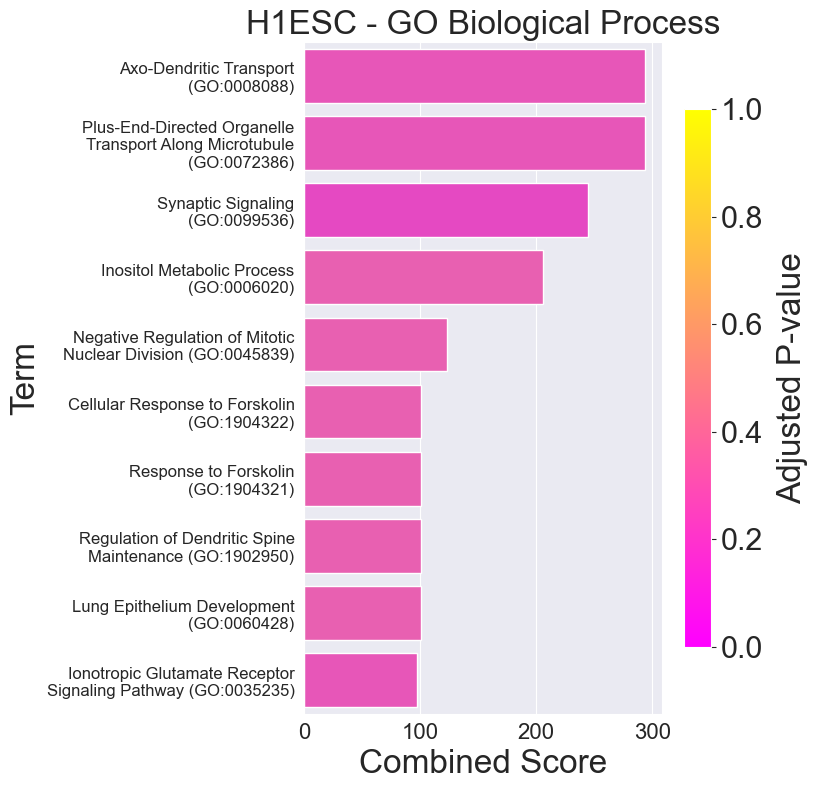

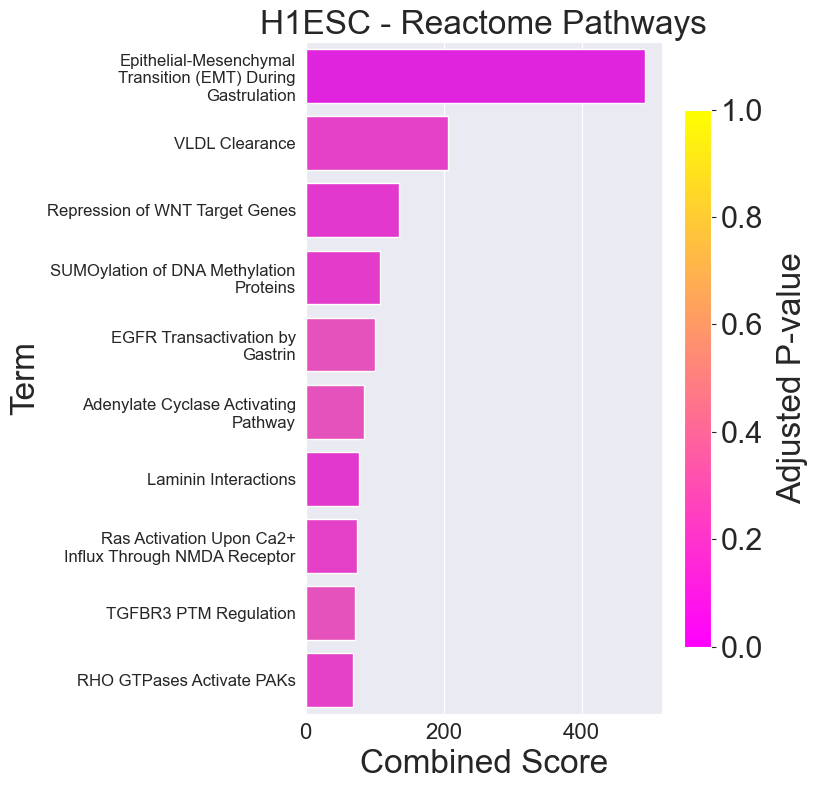

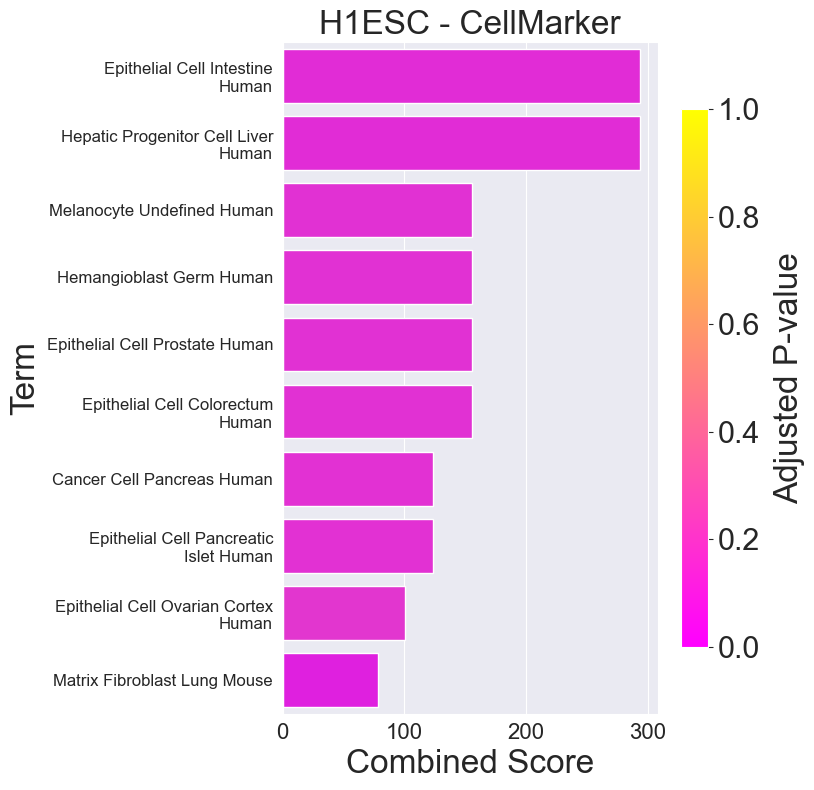

In [13]:
dotplot(get_enrichment_results(h1esc_genes, gene_sets='GO_Biological_Process_2025'), title="H1ESC - GO Biological Process",
        plot_path="figs/exp4_h1esc_enrichment_go.png")
dotplot(get_enrichment_results(h1esc_genes, gene_sets='Reactome_Pathways_2024'), title="H1ESC - Reactome Pathways",
        plot_path="figs/exp4_h1esc_enrichment_reactome.png")
dotplot(get_enrichment_results(h1esc_genes, gene_sets='CellMarker_2024'), title="H1ESC - CellMarker",
        plot_path="figs/exp4_h1esc_enrichment_cellmarker.png")
print("H1ESC upregulated jumper genes:")
print("\n".join(h1esc_genes))

In [14]:
_, hffc6_genes = get_genes_from_2_cell_lines(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    log2fc_threshold=2,
    padj_threshold=0.05
)

/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/3448118802.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=fontsize // 2)
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/3448118802.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=fontsize // 2)
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/3448118802.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=font

HFFC6 upregulated jumper genes:
ITGA5
None
None
FRMD6
PPARG
CLIP4
MAML2
NR1D1
ALKBH3
TOB1
FILIP1L
PYROXD2
POSTN
DAB2
ELK3
ANXA11
PCGF5
DPF3
OSTF1
ERCC6
ADCY7
SEMA5A
SIRPA
SLIT2
ABI3BP
FGF5
SEPSECS-AS1
SLC14A1
P3H4
SUMF1
RPS6KA4
VDR
CAP2
COL11A1
CPT1A
HRH1
LINC02777
TENM4
SPOCD1
SBDSP1
SCUBE3
PRR5L
ITGBL1
SNHG18
IGFBP7-AS1
ADGRL4
MLKL
NBR1
VGLL3
CTF1
PHTF2
MICAL2
GDF15
MYPN
SCP2
TNFRSF19
CD44
PRADC1
NAV3
GABBR2
DPYD
LPCAT2
CPQ
WLS
CRYL1
TGFBR2
PLAT
LYRM4-AS1
ZNF436
FOXK1
CNTN3
ITGB1
BMPER
CAST
VSIR
TRMT9B
RETSAT
CHCHD2
DCBLD2
JCAD
RHOBTB3
GAS2L1
ARL6IP5
FKBP10
ARHGAP24
KANK2
TNRC18
IGFBP7
FBXL2
KCNQ5
MRGPRF
NLRC5
ANKRD2
RTN4RL1
KIAA1549L
NTN4
TRIM8
TBC1D19
PRKD1
LARP6
CPPED1
STARD13
CPEB2
SBDS
IL7R
KIFC3
TBC1D2
ADAM9
TGFB3
NFIA
CTHRC1
RTF2
MSRB3
RFTN1
None
ITGA2
IFIT3
CISD3
CDK6
NXNL2
DHRS1
ITGB1BP1
PIK3IP1
TOX2
PLAUR
NPIPB2
EML5
None
PDE4B
SIM1
None
B3GNT9
SCARNA21
SP2-AS1
KDM6B
KIF23-AS1
NOX5
NT5E
GNG11
CYTH3
ASPN
SERPINB6
OSBPL3
TRAM2
RFX8
COL6A2
None
LOXL4
FOSL2-AS1
MKX
CUEDC1
None


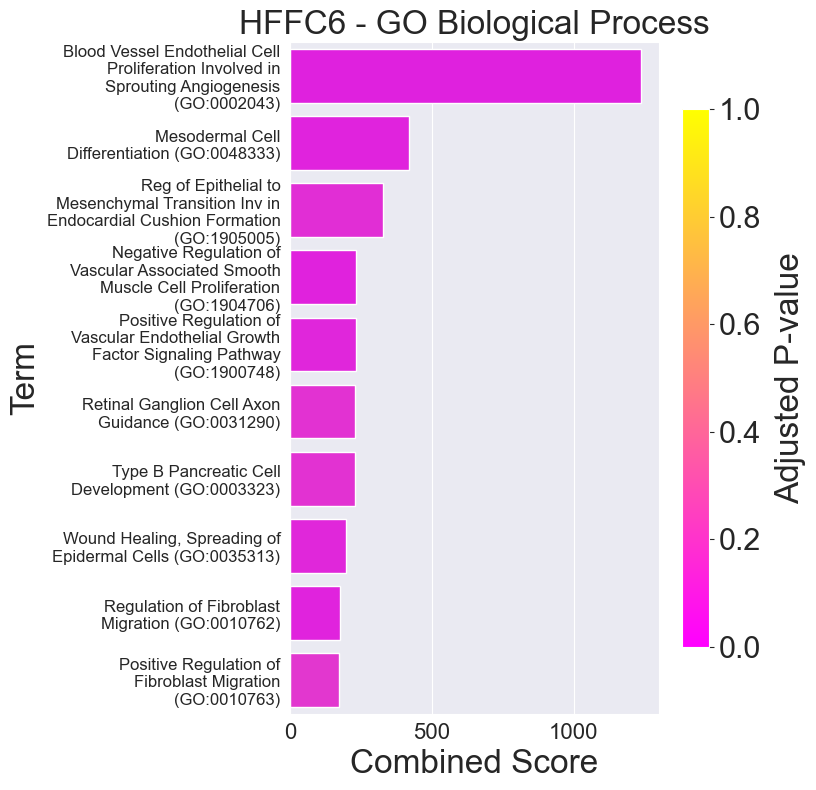

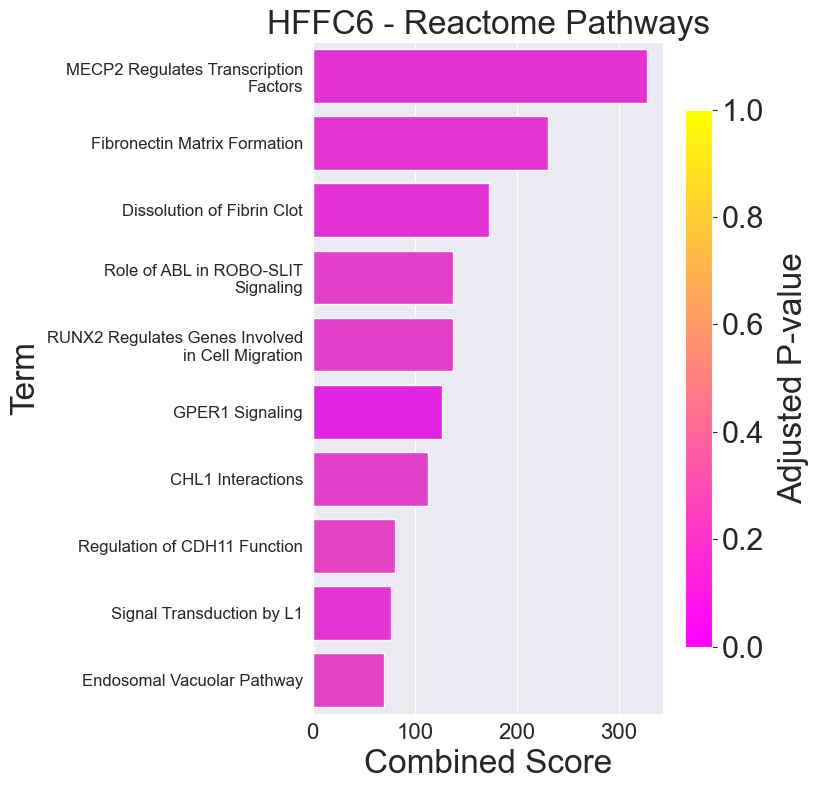

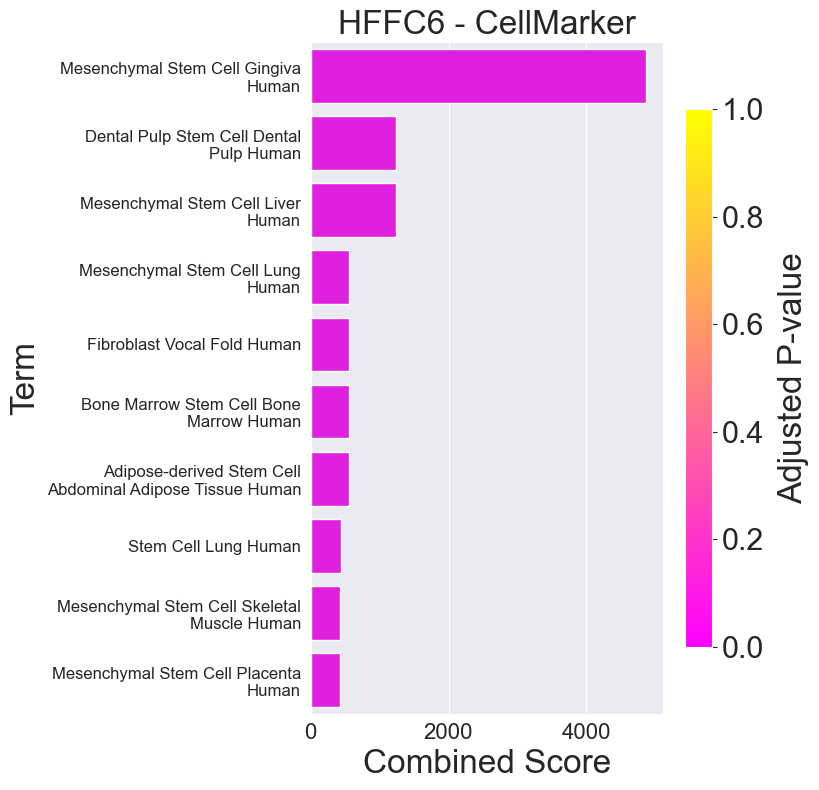

In [15]:
dotplot(get_enrichment_results(hffc6_genes, gene_sets='GO_Biological_Process_2025'), title="HFFC6 - GO Biological Process",
        plot_path="figs/exp4_hffc6_enrichment_go.png")
dotplot(get_enrichment_results(hffc6_genes, gene_sets='Reactome_Pathways_2024'), title="HFFC6 - Reactome Pathways",
        plot_path="figs/exp4_hffc6_enrichment_reactome.png")
dotplot(get_enrichment_results(hffc6_genes, gene_sets='CellMarker_2024'), title="HFFC6 - CellMarker",
        plot_path="figs/exp4_hffc6_enrichment_cellmarker.png")
print("HFFC6 upregulated jumper genes:")
print("\n".join(hffc6_genes))

In [16]:
_, gm12878_genes = get_genes_from_2_cell_lines(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    log2fc_threshold=2,
    padj_threshold=0.05
)

/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/3448118802.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=fontsize // 2)
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/3448118802.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=fontsize // 2)
/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_18978/3448118802.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(label.get_text(), width=30)) for label in ax.get_yticklabels()], fontsize=font

GM12878 upregulated jumper genes:
AICDA
CGAS
MCOLN2
RPS6KA5
MORC2-AS1
STIMATE-MUSTN1
SLC39A8
GPR132
IL15RA
TPTEP2
DENND6B
None
NCALD
ERV3-1
MFSD2A
GIPR
HMSD
SLC6A4
S1PR4
ITGAL
CA13
SUSD3
CD40
OTULIN-DT
None
PILRA
CD27
STAT5A
ASB2
LINC01258
TAF4B
SP4
LSP1
TEX21P
PCED1B-AS1
None
MIF4GD
NUP210
PRORSD1P
ADAM22
AK4
None
PAQR8
PNP
SNN
FSBP
ORC1
None
HNF1B
ST3GAL6
TRPV3
PIF1
LINC01585
PLEKHG7
LIM2-AS1
EFCAB6-DT
SLFN12L
CD22
VCAM1
SGO1-AS1
PIK3CD
MITA1
TNFRSF17
GPR65
UBR5-DT
MCM5
E2F5
SKAP1
None
BCL2A1
MAP2K6
AGMAT
PARP8
None
MMD
MX2
DNA2
CDH23
AKAP1-DT
PDLIM1P4
None
HESX1
POLD1
APOL6
RGS6
ALDOC
None
ATP8B1-AS1
GUSBP11
LINC01572
None
ALOX12P2
JAK3
None
PPCDC
SHISAL2A
TSPAN18
ZNF165
RESF1
LINC02851
ZNF117
RPS6KB2-AS1
REL
IFNG-AS1
WDFY4
SINHCAF
DUSP22
None
RASA4CP
IL23A
None
RAC2
RALGAPA2
PSME2
None
RASSF6
None
PPM1K
NPIPB11
ZNF519
TEC
HLA-F
None
TRD-AS1
None
CEP250-AS1
ARID3B
BIRC3
UNC13D
ARHGAP25
ATP2A3
None
MAP3K14-AS1
None
ARHGDIB
TESPA1
INSR
CYTH4
SPTBN2
CIITA
TUBA8
SPINT2
PAX5
None
TET3
No

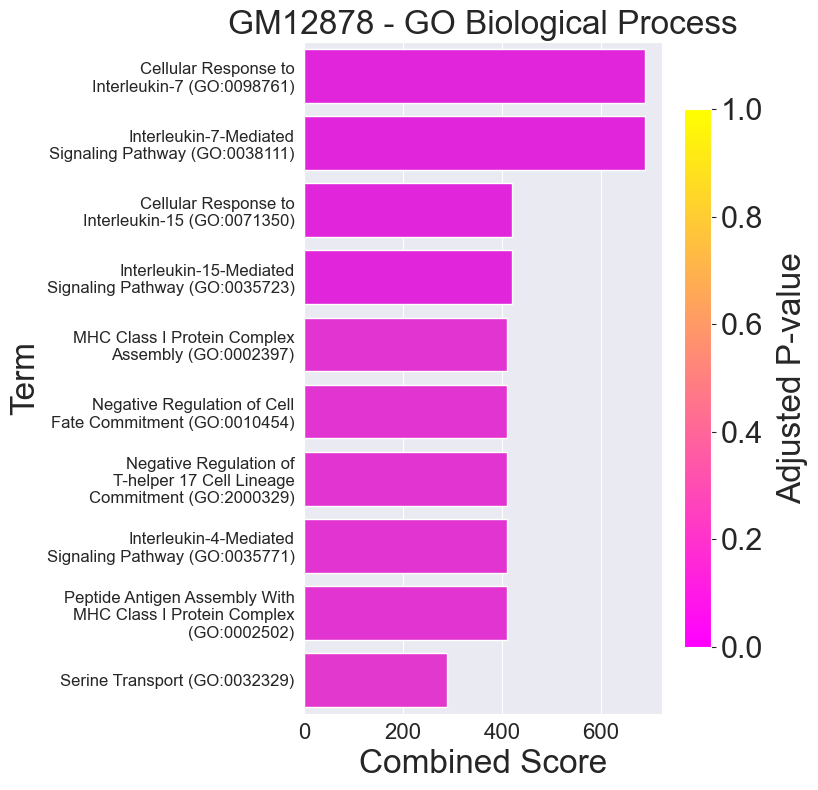

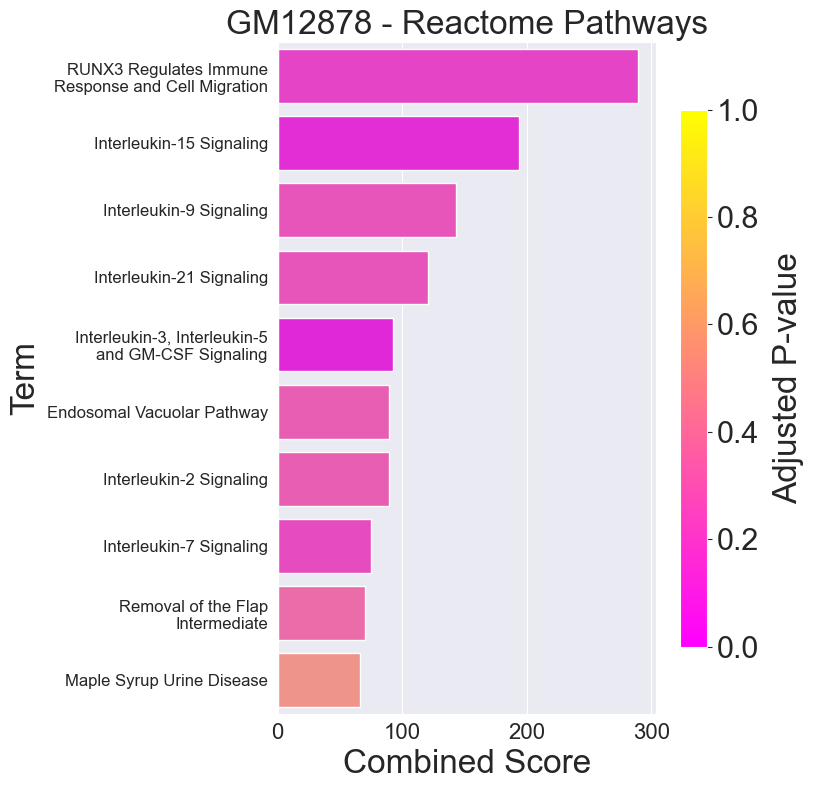

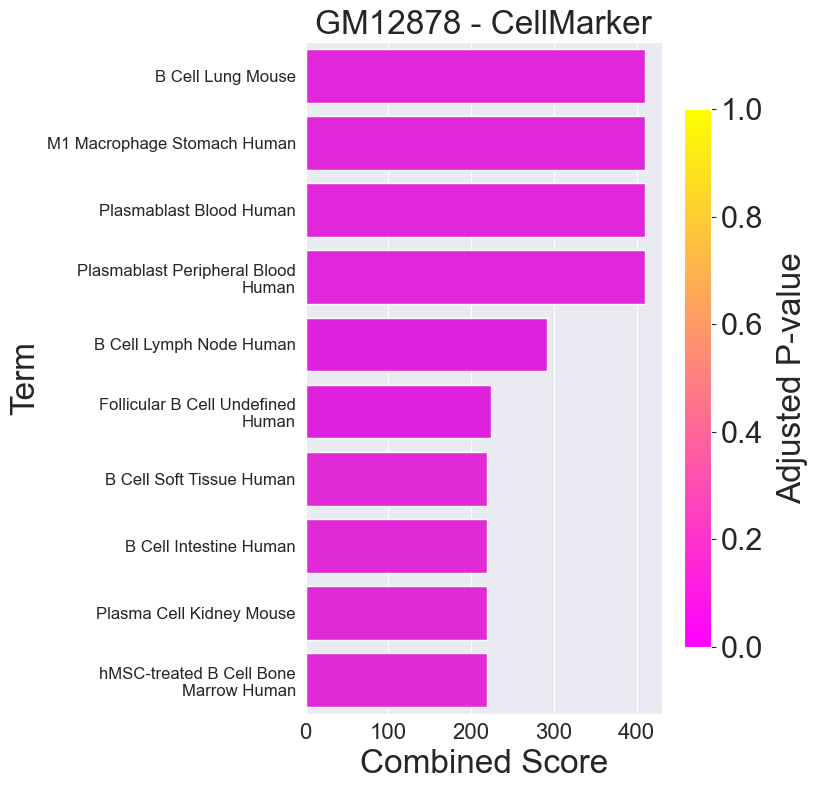

In [17]:
dotplot(get_enrichment_results(gm12878_genes, gene_sets='GO_Biological_Process_2025'), title="GM12878 - GO Biological Process", plot_path="figs/exp4_gm12878_enrichment_go.png")
dotplot(get_enrichment_results(gm12878_genes, gene_sets='Reactome_Pathways_2024'), title="GM12878 - Reactome Pathways", plot_path="figs/exp4_gm12878_enrichment_reactome.png")
dotplot(get_enrichment_results(gm12878_genes, gene_sets='CellMarker_2024'), title="GM12878 - CellMarker", plot_path="figs/exp4_gm12878_enrichment_cellmarker.png")
print("GM12878 upregulated jumper genes:")
print("\n".join(gm12878_genes))

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from textwrap import wrap
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def dotplot2(
    results,
    cell_order=('GM12878', 'HFFC6', 'H1ESC'),
    figsize=(8, 12),
    fontsize=20,
    title="Top enriched pathways\n(size ~ enrichment score)",
    xlabel="Cell type",
    ylabel="",
    marker_color="#D39A1A",   # gold-like color used in example image
    min_marker=160,
    max_marker=2200,
    plot_path=None
):
    """
    results: DataFrame with columns: 'Term', 'CellType', 'Combined Score', 'Adjusted P-value' (optional)
    cell_order: tuple/list with the three cell types in the desired left->right order
    """

    # Validate presence of columns
    required = {'Term', 'CellType', 'Combined Score'}
    missing = required - set(results.columns)
    if missing:
        raise ValueError(f"results is missing required columns: {missing}")

    # order of y-terms (preserve order if present, otherwise take unique)
    terms = list(results['Term'].unique())
    n_terms = len(terms)
    y_positions = np.arange(n_terms)[::-1]   # top-to-bottom

    # mapping term -> y index
    term_to_y = {term: y for term, y in zip(terms, y_positions)}

    # mapping cell -> x position
    x_positions = np.arange(len(cell_order))
    cell_to_x = {cell: x for cell, x in zip(cell_order, x_positions)}

    # sizes: scale Combined Score to sensible marker sizes
    cs_values = results['Combined Score'].astype(float)
    cs_min, cs_max = cs_values.min(), cs_values.max()
    denom = cs_max - cs_min if cs_max != cs_min else 1.0

    def scale_size(cs):
        return ((cs - cs_min) / denom) * (max_marker - min_marker) + min_marker

    fig, ax = plt.subplots(figsize=figsize)

    # horizontal dotted guide lines
    for y in y_positions:
        ax.hlines(y, xmin=-0.5, xmax=len(cell_order)-0.5, colors='lightgray', linestyles='dotted', linewidth=1)

    # vertical dashed separators (draw at each cell x)
    for x in x_positions:
        ax.axvline(x=x, color='lightgray', linestyle='dashed', linewidth=1, zorder=0)

    # Plot each row as a single 'X' marker at (cell_x, term_y)
    for _, row in results.iterrows():
        term = row['Term']
        cell = row['CellType']
        if term not in term_to_y or cell not in cell_to_x:
            # skip unexpected entries
            continue
        x = cell_to_x[cell]
        y = term_to_y[term]
        s = scale_size(float(row['Combined Score']))
        # alpha can reflect Adjusted P-value if present (smaller p -> stronger -> higher alpha)
        alpha = 1.0
        if 'Adjusted P-value' in results.columns:
            try:
                adj = float(row['Adjusted P-value'])
                alpha = max(0.25, 1 - adj)  # clamp so faint markers still visible
            except Exception:
                alpha = 1.0
        ax.scatter([x], [y], s=s, marker='X', color=marker_color, linewidths=2.5, edgecolors='black', alpha=alpha, zorder=3)

    # axis formatting
    ax.set_xlim(-0.6, len(cell_order)-0.4)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(cell_order, fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=fontsize+2, labelpad=12, fontweight='bold')

    # y-axis labels: wrap and place at left
    wrapped = ['\n'.join(wrap(t, width=30)) for t in terms]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(wrapped, fontsize=fontsize // 2, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=fontsize, fontweight='bold')

    # Title
    ax.set_title(title, fontsize=fontsize+4, pad=20, fontweight='bold')

    # Remove top/right spines, keep left spine for axis line similar to picture
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_visible(False)

    # x tick baseline thick line (mimics bold baseline in example)
    ax.axhline(y=y_positions.min()-1.2, color='black', linewidth=3.0, zorder=2)

    # tidy up
    ax.invert_yaxis()  # so first term appears at top
    plt.tight_layout()

    if plot_path:
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')

    return fig, ax


In [19]:
h1esc_reactomes = get_enrichment_results(h1esc_genes, gene_sets='Reactome_Pathways_2024')
hffc6_reactomes = get_enrichment_results(hffc6_genes, gene_sets='Reactome_Pathways_2024')
gm12878_reactomes = get_enrichment_results(gm12878_genes, gene_sets='Reactome_Pathways_2024')

h1esc_reactomes['CellType'] = 'H1ESC'
hffc6_reactomes['CellType'] = 'HFFC6'
gm12878_reactomes['CellType'] = 'GM12878'

(<Figure size 800x1200 with 1 Axes>,
 <Axes: title={'center': 'Top enriched pathways\n(size ~ enrichment score)'}, xlabel='Cell type'>)

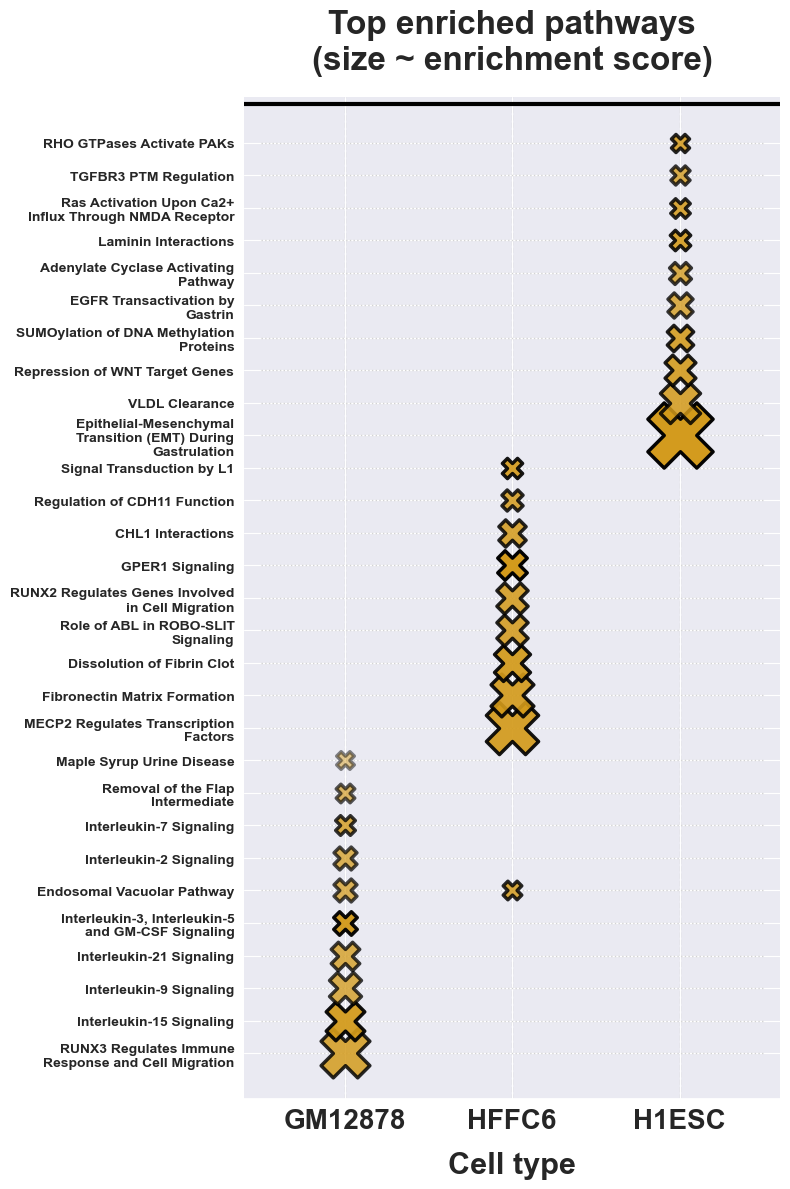

In [53]:
dotplot2(pd.concat([gm12878_reactomes, hffc6_reactomes, h1esc_reactomes]), fontsize=20, plot_path="figs/exp4_full_enrichment_reactomes.png")

In [21]:
_, h1esc_jumps_only = get_comparison_table_2_cell_lines(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=False
)

_, h1esc_expression_only = get_comparison_table_2_cell_lines(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=False,
    enable_expression_filtering=True
)

_, h1esc_jumps_expression_both = get_comparison_table_2_cell_lines(
    gm12878_gene_to_closest_avg_enhancer_all,
    h1esc_gene_to_closest_avg_enhancer_all,
    gm12878_vs_h1esc_results_df,
    "GM12878",
    "H1ESC",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=True
)

h1esc_jumps_only = h1esc_jumps_only[['min_dist_GM12878', 'min_dist_H1ESC', 'quartile_cat_GM12878', 'quartile_cat_H1ESC']]
h1esc_jumps_only.to_csv("../data/for_paper/h1esc_jumps_only.csv")

h1esc_expression_only = h1esc_expression_only[['log2FoldChange', 'padj']]
h1esc_expression_only.to_csv("../data/for_paper/h1esc_expression_only.csv")

h1esc_jumps_expression_both = h1esc_jumps_expression_both[['min_dist_GM12878', 'min_dist_H1ESC', 'quartile_cat_GM12878', 'quartile_cat_H1ESC', 'log2FoldChange', 'padj']]
h1esc_jumps_expression_both.to_csv("../data/for_paper/h1esc_jumps_expression_both.csv")

In [22]:
_, hffc6_jumps_only = get_comparison_table_2_cell_lines(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=False
)

_, hffc6_expression_only = get_comparison_table_2_cell_lines(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=False,
    enable_expression_filtering=True
)

_, hffc6_jumps_expression_both = get_comparison_table_2_cell_lines(
    h1esc_gene_to_closest_avg_enhancer_all,
    hffc6_gene_to_closest_avg_enhancer_all,
    h1esc_vs_hffc6_results_df,
    "H1ESC",
    "HFFC6",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=True
)

hffc6_jumps_only = hffc6_jumps_only[
    ['min_dist_H1ESC', 'min_dist_HFFC6',
     'quartile_cat_H1ESC', 'quartile_cat_HFFC6']
]
hffc6_jumps_only.to_csv("../data/for_paper/hffc6_jumps_only.csv")

hffc6_expression_only = hffc6_expression_only[['log2FoldChange', 'padj']]
hffc6_expression_only.to_csv("../data/for_paper/hffc6_expression_only.csv")

hffc6_jumps_expression_both = hffc6_jumps_expression_both[
    ['min_dist_H1ESC', 'min_dist_HFFC6',
     'quartile_cat_H1ESC', 'quartile_cat_HFFC6',
     'log2FoldChange', 'padj']
]
hffc6_jumps_expression_both.to_csv("../data/for_paper/hffc6_jumps_expression_both.csv")

/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [23]:
_, gm12878_jumps_only = get_comparison_table_2_cell_lines(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=False
)

_, gm12878_expression_only = get_comparison_table_2_cell_lines(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=False,
    enable_expression_filtering=True
)

_, gm12878_jumps_expression_both = get_comparison_table_2_cell_lines(
    hffc6_gene_to_closest_avg_enhancer_all,
    gm12878_gene_to_closest_avg_enhancer_all,
    hffc6_vs_gm12878_results_df,
    "HFFC6",
    "GM12878",
    log2fc_threshold=2,
    padj_threshold=0.05,
    enable_jump_filtering=True,
    enable_expression_filtering=True
)

gm12878_jumps_only = gm12878_jumps_only[
    ['min_dist_HFFC6', 'min_dist_GM12878',
     'quartile_cat_HFFC6', 'quartile_cat_GM12878']
]
gm12878_jumps_only.to_csv("../data/for_paper/gm12878_jumps_only.csv")

gm12878_expression_only = gm12878_expression_only[['log2FoldChange', 'padj']]
gm12878_expression_only.to_csv("../data/for_paper/gm12878_expression_only.csv")

gm12878_jumps_expression_both = gm12878_jumps_expression_both[
    ['min_dist_HFFC6', 'min_dist_GM12878',
     'quartile_cat_HFFC6', 'quartile_cat_GM12878',
     'log2FoldChange', 'padj']
]
gm12878_jumps_expression_both.to_csv("../data/for_paper/gm12878_jumps_expression_both.csv")
